In [1]:
import torch

def check_cuda_availability():
    if torch.cuda.is_available():
        print('CUDA is available')
        device = torch.device('cuda')
    else:
        print('CUDA in NOT available')
        device = torch.device('cpu')

    return device

def check_mps_availability():
    if torch.backends.mps.is_available():
        print('MPS is available')
        device = torch.device('mps')
    else:
        print('MPS in NOT available')
        device = torch.device('cpu')

    return device

In [2]:
import platform

if platform.system() == 'Darwin':
    print('macOS')
    device = check_mps_availability()
else:
    device = check_cuda_availability()

device

CUDA is available


device(type='cuda')

In [3]:
# MNIST Data Load
from torchvision import datasets, transforms

train_data = datasets.MNIST(
    root='./',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_data = datasets.MNIST(
    root='./',
    train=False,
    transform=transforms.ToTensor()
)

len(train_data), len(test_data)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.75MB/s]


(60000, 10000)

In [4]:
# Data Loader
batch_size = 256

train_loader = torch.utils.data.DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    shuffle=False
)

In [18]:
# Model
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class CNN(nn.Module):
    # Layer 정의
    def __init__(self):
        # 부모 클래스 상속 (없으면 덮어씀)
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1, padding='same')
        self.conv2 = nn.Conv2d(32, 64, 3, 1, padding='same')
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 1000)
        self.fc2 = nn.Linear(1000, 10)

    # Connect
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)

        return output

print(CNN())

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [ ]:
# !pip install torchinfo

In [11]:
# Model Summary
# batch_size 조절하며 메모리 예상 가능
from torchinfo import summary

summary(CNN(),
        input_size=(batch_size * 2, 1, 28, 28),
        col_width=14,
        depth=5,
        row_settings=['depth', 'var_names'],
        col_names=['kernel_size', 'output_size', 'num_params'])

Layer (type (var_name):depth-idx)        Kernel Shape   Output Shape   Param #
CNN (CNN)                                --             [512, 10]      --
├─Conv2d (conv1): 1-1                    [3, 3]         [512, 32, 28, 28] 320
├─Conv2d (conv2): 1-2                    [3, 3]         [512, 64, 14, 14] 18,496
├─Dropout (dropout): 1-3                 --             [512, 64, 7, 7] --
├─Linear (fc1): 1-4                      --             [512, 1000]    3,137,000
├─Linear (fc2): 1-5                      --             [512, 10]      10,010
Total params: 3,165,826
Trainable params: 3,165,826
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 3.60
Input size (MB): 1.61
Forward/backward pass size (MB): 158.28
Params size (MB): 12.66
Estimated Total Size (MB): 172.55

In [19]:
# Compile
learning_rate = 0.0001

model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [14]:
# Data Loader 동작 확인
epochs = 5

for epoch in range(epochs):
    print('---')

    for data, target in train_loader:
        print(f'data: {data.shape}')
        print(f'target: {target.shape}')
        break

---
data: torch.Size([256, 1, 28, 28])
target: torch.Size([256])
---
data: torch.Size([256, 1, 28, 28])
target: torch.Size([256])
---
data: torch.Size([256, 1, 28, 28])
target: torch.Size([256])
---
data: torch.Size([256, 1, 28, 28])
target: torch.Size([256])
---
data: torch.Size([256, 1, 28, 28])
target: torch.Size([256])


In [21]:
# Train
def test(model):
    model.eval()

    correct = 0
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        prediction = output.data.max(1)[1]
        correct += prediction.eq(target.data).sum()

    acc = 100. * correct / len(test_loader.dataset)

    return acc.cpu().item()

model.train()

i = 1
loss_list = []
acc_list = []

for epoch in range(epochs):
    correct = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        # Optimizer Reset
        optimizer.zero_grad()
        # Predict
        output = model(data)

        # Get Loss
        loss = criterion(output, target)
        # Back Propagation
        loss.backward()

        # Weight, Bias Update
        optimizer.step()

        loss_list.append(loss.item())
    acc = test(model)
    acc_list.append(acc)

    print(f'Epoch: {epoch} || Loss: {loss.item()} || Accuracy: {acc}')

Epoch: 0 || Loss: 0.22215084731578827 || Accuracy: 95.15999603271484
Epoch: 1 || Loss: 0.12964589893817902 || Accuracy: 96.83999633789062
Epoch: 2 || Loss: 0.09116718918085098 || Accuracy: 97.43999481201172
Epoch: 3 || Loss: 0.0858633890748024 || Accuracy: 98.0199966430664
Epoch: 4 || Loss: 0.020195571705698967 || Accuracy: 98.30999755859375


In [22]:
acc_list

[95.15999603271484,
 96.83999633789062,
 97.43999481201172,
 98.0199966430664,
 98.30999755859375]

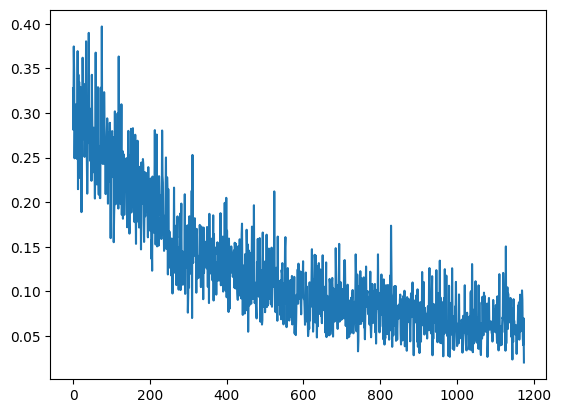

In [23]:
import matplotlib.pyplot as plt

plt.plot(loss_list)

plt.show()

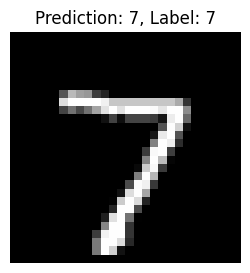

In [24]:
# 예측 결과 확인
dataiter = iter(test_loader)
images, labels = next(dataiter)

image = images[0].to(device)

# Predict
model.eval()

with torch.no_grad():
    output = model(image.unsqueeze(0))
    prediction = output.argmax(dim=1, keepdim=True)

image = image.cpu().squeeze()

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap='gray')
plt.title(f'Prediction: {prediction.item()}, Label: {labels[0].item()}')
plt.axis('off')

plt.show()